In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('./asistencia.csv')
df["Marca temporal"] = pd.to_datetime(df["Marca temporal"], dayfirst=True)
ic_df = df[df["Marca temporal"].dt.year == 2026]

In [3]:
ic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166 entries, 111 to 276
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Marca temporal                   166 non-null    datetime64[ns]
 1   Dirección de correo electrónico  166 non-null    object        
 2   Nombres y apellido               166 non-null    object        
 3   Género                           166 non-null    object        
 4   Carrera                          166 non-null    object        
 5   Fecha de hoy                     0 non-null      object        
dtypes: datetime64[ns](1), object(5)
memory usage: 9.1+ KB


In [4]:
# ── Paleta de colores del club ──
VERDE_CLUB = "#2E7D32"
GRIS_CLUB = "#757575"
COLORES_CLUB = [VERDE_CLUB, GRIS_CLUB]


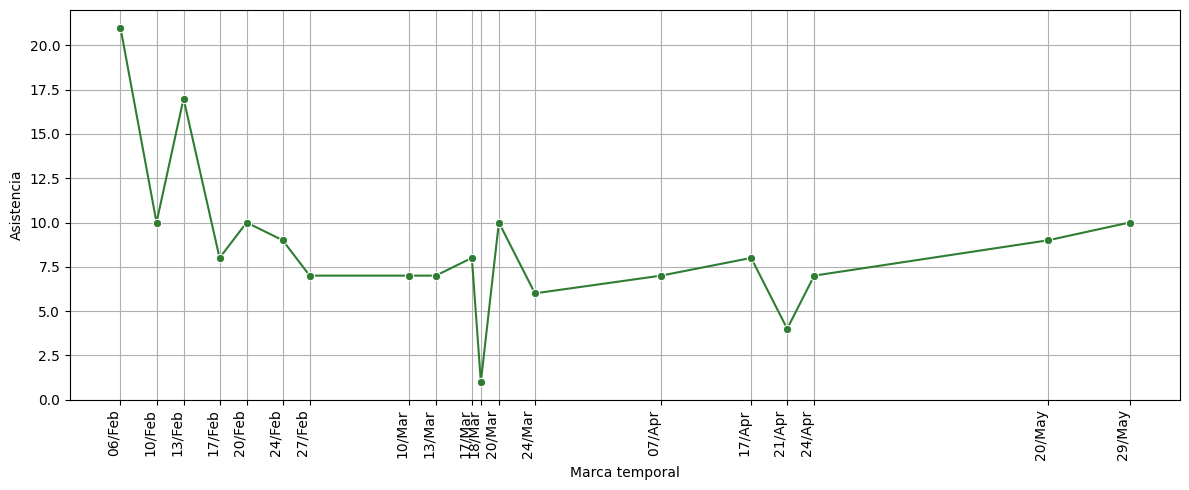

In [21]:
count_per_day = (
    ic_df.groupby(ic_df["Marca temporal"].dt.normalize())
         .size()
         .reset_index(name="Asistencia")
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=count_per_day,
    x="Marca temporal",
    y="Asistencia",
    marker="o",
    color=VERDE_CLUB,
    ax=ax
)

ax.set_xticks(count_per_day["Marca temporal"])
ax.set_xticklabels(
    count_per_day["Marca temporal"].dt.strftime("%d/%b"),
    rotation=90,
    ha="right"
)


plt.grid()
plt.tight_layout()
plt.savefig("./img/asistencia_por_dia.png", bbox_inches="tight")
plt.show()

In [6]:
ic_df["primera_vez"] = (
    ic_df["Marca temporal"]
    == ic_df.groupby("Dirección de correo electrónico")["Marca temporal"].transform("min")
)

/tmp/ipykernel_55058/3655355907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ic_df["primera_vez"] = (


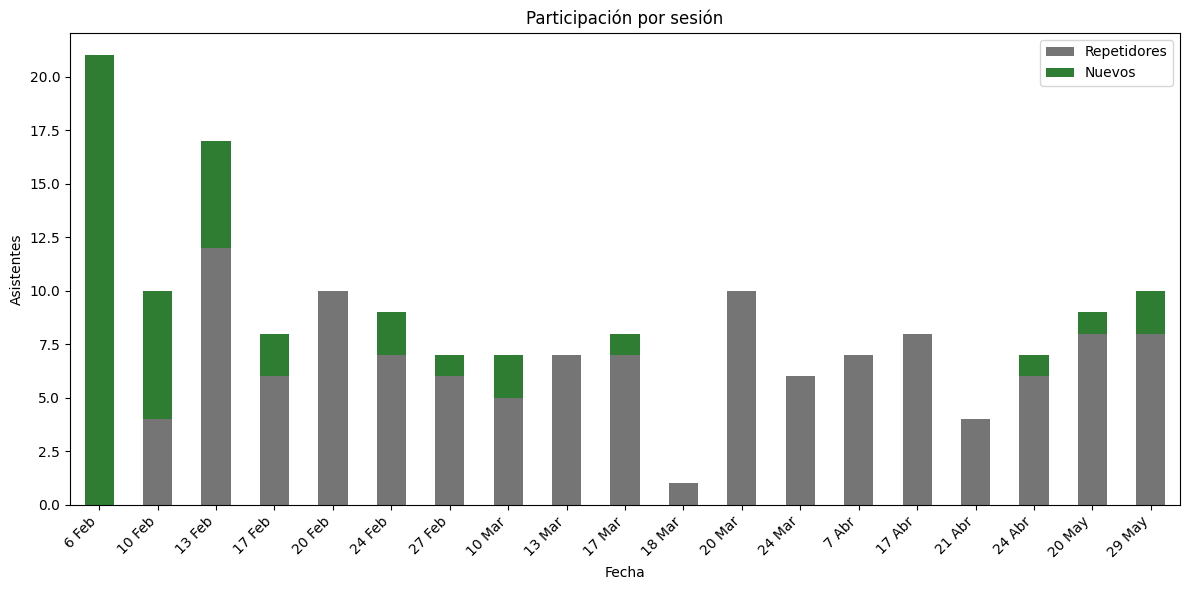

In [22]:
attendance = (
    ic_df.groupby([
        ic_df["Marca temporal"].dt.normalize(),
        "primera_vez"
    ])
    .size()
    .unstack(fill_value=0)
)

attendance.columns = ["Repetidores", "Nuevos"]

meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"
}

attendance.index = [
    f"{fecha.day} {meses[fecha.month]}"
    for fecha in attendance.index
]

ax = attendance.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=[GRIS_CLUB, VERDE_CLUB]
)

ax.set_title("Participación por sesión")
ax.set_xlabel("Fecha")
ax.set_ylabel("Asistentes")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("./img/participacion_por_sesion.png", bbox_inches="tight")
plt.show()

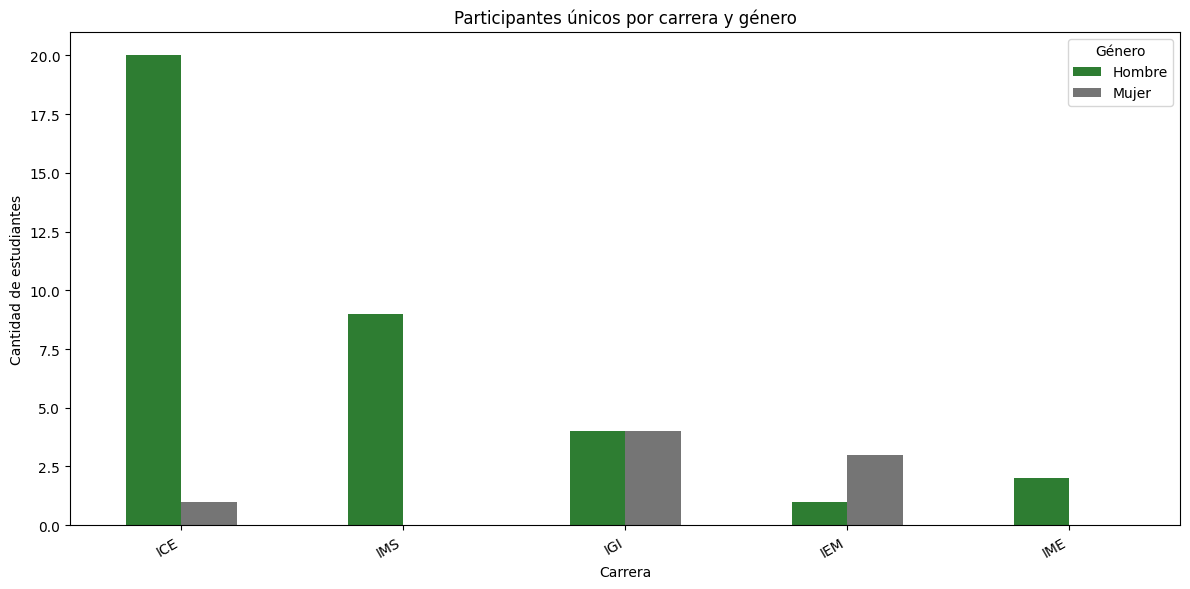

In [23]:
asistentes_unicos = (
    ic_df
    .sort_values("Marca temporal")
    .groupby("Dirección de correo electrónico")
    .first()
)

carrera_genero = (
    asistentes_unicos
    .groupby(["Carrera", "Género"])
    .size()
    .unstack(fill_value=0)
)

carrera_genero["Total"] = carrera_genero.sum(axis=1)

carrera_genero = (
    carrera_genero
    .sort_values("Total", ascending=False)
    .drop(columns="Total")
)

ax = carrera_genero.plot(
    kind="bar",
    figsize=(12, 6),
    color=[VERDE_CLUB, GRIS_CLUB]
)

ax.set_title("Participantes únicos por carrera y género")
ax.set_xlabel("Carrera")
ax.set_ylabel("Cantidad de estudiantes")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("./img/participantes_por_carrera_genero.png", bbox_inches="tight")
plt.show()

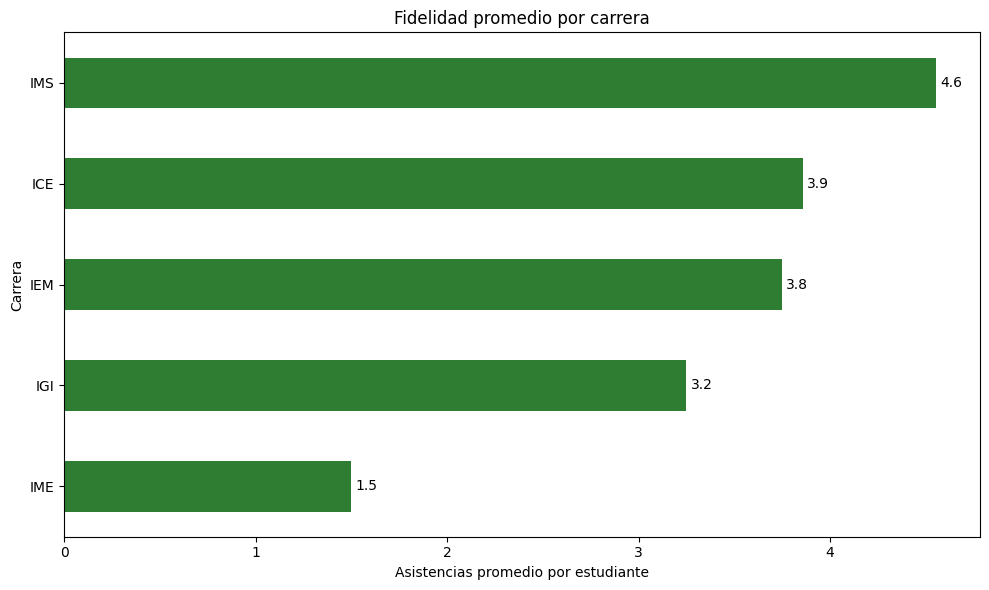

In [24]:
# Un registro por estudiante
asistentes_unicos = (
    ic_df
    .sort_values("Marca temporal")
    .groupby("Dirección de correo electrónico")
    .first()
)

# Asistencias acumuladas por carrera
asistencias_por_carrera = (
    ic_df
    .groupby("Carrera")
    .size()
)

# Participantes únicos por carrera
unicos_por_carrera = (
    asistentes_unicos
    .groupby("Carrera")
    .size()
)

# Fidelidad promedio
fidelidad = (
    asistencias_por_carrera
    .div(unicos_por_carrera)
    .sort_values(ascending=True)
)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

fidelidad.plot(
    kind="barh",
    ax=ax,
    color=VERDE_CLUB
)

ax.set_title("Fidelidad promedio por carrera")
ax.set_xlabel("Asistencias promedio por estudiante")
ax.set_ylabel("Carrera")

# Mostrar valor al final de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3
    )

plt.tight_layout()
plt.savefig("./img/fidelidad_por_carrera.png", bbox_inches="tight")
plt.show()

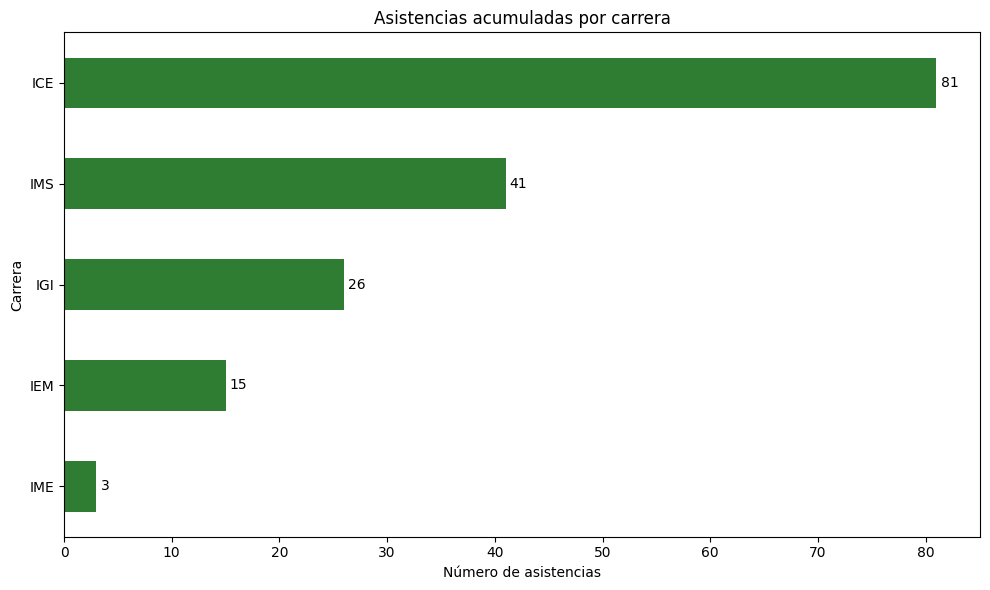

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

(
    ic_df.groupby("Carrera")
         .size()
         .sort_values()
         .plot(kind="barh", ax=ax, color=VERDE_CLUB)
)

ax.set_title("Asistencias acumuladas por carrera")
ax.set_xlabel("Número de asistencias")
ax.set_ylabel("Carrera")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig("./img/asistencias_acumuladas_por_carrera.png", bbox_inches="tight")
plt.show()

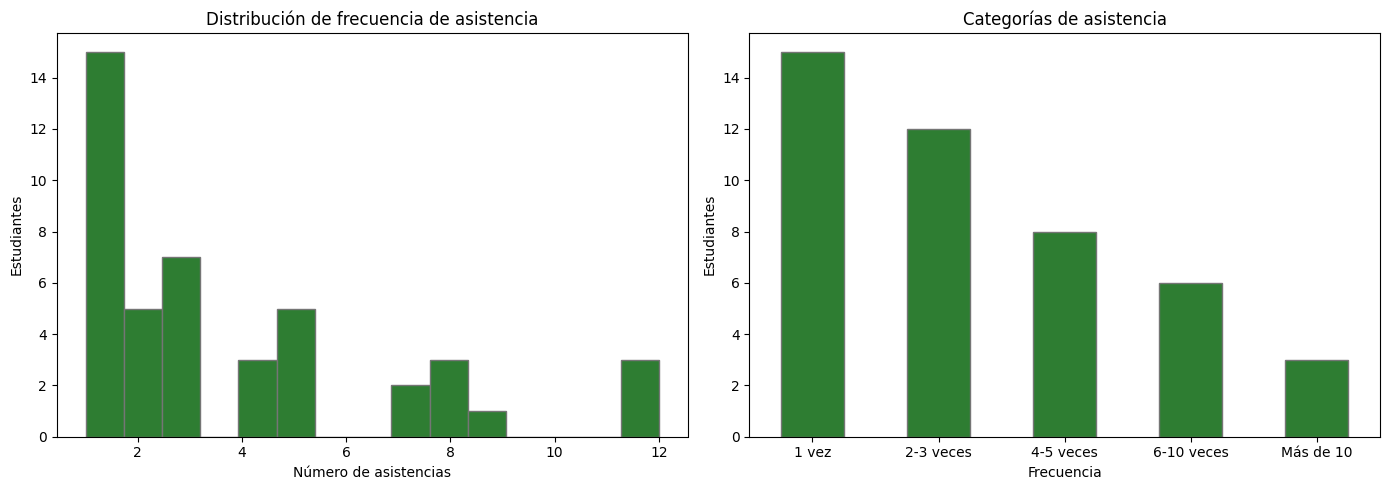

Resumen de frecuencia de asistencia:
count    44.000000
mean      3.772727
std       3.226804
min       1.000000
25%       1.000000
50%       3.000000
75%       5.000000
max      12.000000
dtype: float64

  15 estudiantes asistieron 1 vez
  12 estudiantes asistieron 2-3 veces
  8 estudiantes asistieron 4-5 veces
  6 estudiantes asistieron 6-10 veces
  3 estudiantes asistieron Más de 10


In [26]:
# ════════════════════════════════════════════
# Nivel 2: Métricas de retención
# ════════════════════════════════════════════

# ── Frecuencia de asistencia individual ──
frecuencia = ic_df.groupby("Dirección de correo electrónico").size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
frecuencia.plot(
    kind="hist", bins=15, ax=axes[0],
    color=VERDE_CLUB, edgecolor=GRIS_CLUB
)
axes[0].set_title("Distribución de frecuencia de asistencia")
axes[0].set_xlabel("Número de asistencias")
axes[0].set_ylabel("Estudiantes")

# Categorías
cats = pd.cut(
    frecuencia,
    bins=[0, 1, 3, 5, 10, 100],
    labels=["1 vez", "2-3 veces", "4-5 veces", "6-10 veces", "Más de 10"],
    right=True
)
conteo_cats = cats.value_counts().sort_index()
conteo_cats.plot(
    kind="bar", ax=axes[1],
    color=VERDE_CLUB, edgecolor=GRIS_CLUB
)
axes[1].set_title("Categorías de asistencia")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Estudiantes")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("./img/frecuencia_asistencia.png", bbox_inches="tight")
plt.show()

# Resumen estadístico
print("Resumen de frecuencia de asistencia:")
print(frecuencia.describe())
print()
for label, count in zip(conteo_cats.index, conteo_cats.values):
    print(f"  {count} estudiantes asistieron {label}")


In [12]:
# ── Coeficiente de retención del club ──
asistencias_por_persona = ic_df.groupby("Dirección de correo electrónico").size()
coef_ret = (asistencias_por_persona > 1).mean() * 100

print(f"Coeficiente de retención del club: {coef_ret:.1f}%")
print(f"({(asistencias_por_persona > 1).sum()} de {len(asistencias_por_persona)}",
      f"participantes regresaron al menos una vez)")


Coeficiente de retención del club: 65.9%
(29 de 44 participantes regresaron al menos una vez)


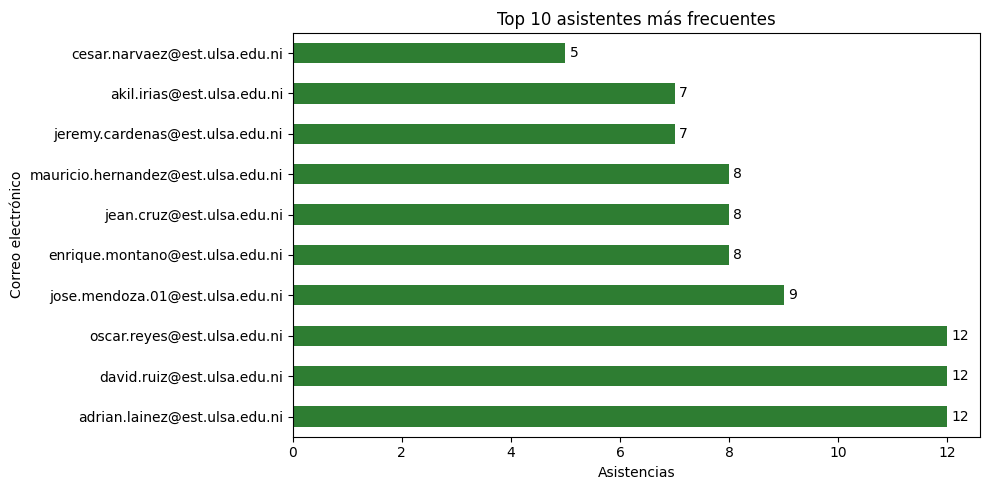

In [27]:
# ── Top 10 asistentes ──
top = (
    ic_df.groupby("Dirección de correo electrónico")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
top.plot(kind="barh", ax=ax, color=VERDE_CLUB)
ax.set_title("Top 10 asistentes más frecuentes")
ax.set_xlabel("Asistencias")
ax.set_ylabel("Correo electrónico")
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.tight_layout()
plt.savefig("./img/top_asistentes.png", bbox_inches="tight")
plt.show()


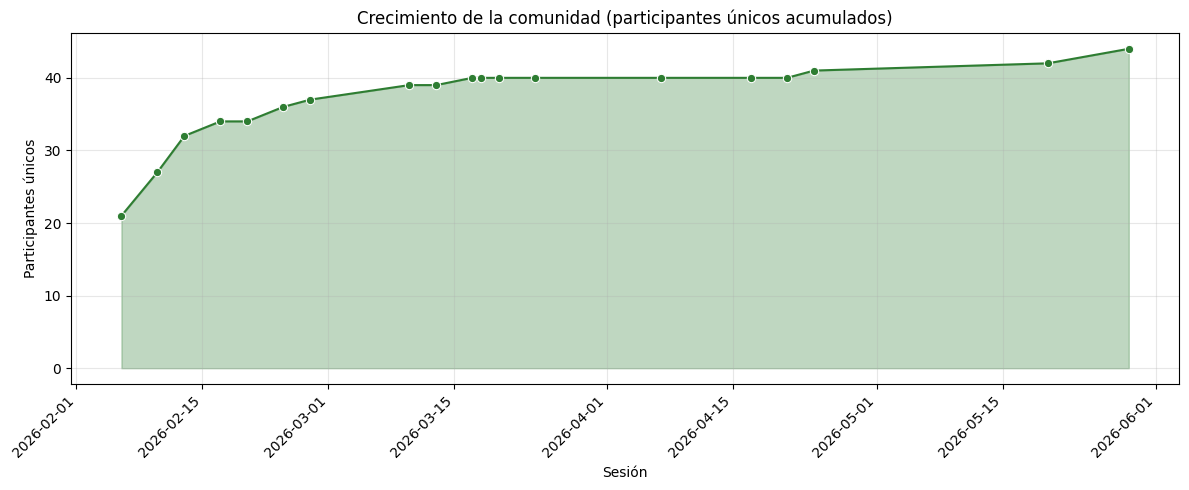

In [28]:
# ════════════════════════════════════════════
# Nivel 3: Análisis temporal
# ════════════════════════════════════════════

# ── Comunidad acumulada ──
sesiones = (
    ic_df
    .sort_values("Marca temporal")
    .groupby(ic_df["Marca temporal"].dt.normalize())
)

comunidad = []
unicos = set()
for fecha, grupo in sesiones:
    unicos.update(grupo["Dirección de correo electrónico"])
    comunidad.append({"Fecha": fecha, "Únicos acumulados": len(unicos)})

comunidad_df = pd.DataFrame(comunidad)

fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=comunidad_df,
    x="Fecha", y="Únicos acumulados",
    marker="o", color=VERDE_CLUB, ax=ax
)
ax.fill_between(
    comunidad_df["Fecha"],
    comunidad_df["Únicos acumulados"],
    alpha=0.3, color=VERDE_CLUB
)
ax.set_title("Crecimiento de la comunidad (participantes únicos acumulados)")
ax.set_ylabel("Participantes únicos")
ax.set_xlabel("Sesión")

plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./img/crecimiento_comunidad.png", bbox_inches="tight")
plt.show()
